# Analyse network results for Pypsa-Earth-Sec
This notebook processes the latest optimization data specified in the config.yaml file and the network .nc file. It generates comprehensive plots and summaries to visualize the results.

This notebook is used to analyse a sector-coupled model run for Algeria using GADM clustering ``alternative_clustering: True``

with a temporal resolution of 24h. 

**Pipeline settings:**

``["sector"]["hydrogen"]["network_routes"]: "gas"``
``["sector"]["hydrogen"]["gas_network_repurposing"]: true``

-> New H2 Pipelines following gas network AND repuroposing
* Gas network as a routing for new H2 pipelines.
* Repurposing of existing gas network.

See [PyPSA-Earth-Sec PR #283](https://github.com/pypsa-meets-earth/pypsa-earth-sec/pull/283)

Sources: 
- Statistics module: https://pypsa.readthedocs.io/en/latest/examples/statistics.html
- Templates and colors: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb

File is needed:
* PyPSA network file (.nc) includes the heating, transprot, and electricity demand information.

## Import packages

In [3]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [17]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# Set your pypsa-earth-sec directory here
PARENT = os.path.realpath("../../pypsa-earth") + "/"
# Set your network path (.nc) here
network_path = PARENT + f"results/DZA-1/postnetworks/elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_10export.nc"
# network_path = PARENT + f"results/DZA-48-GADM-el-netZero-2030-12H/networks/elec_s_48_ec_lcopt_Co2L-12H.nc"
# network_path = PARENT + f"results/DZA-1/prenetworks/elec_s_48_ec_lcopt_Co2L-3H_3H_2030_0.071_AB_presec.nc"
#network_path = PARENT + f"results/elec_s_10_ec_lc3.0_Co2L_3H_2035_0.071_AB_14export.nc"  
n = pypsa.Network(network_path)
# config_path = PARENT + f"/config.yaml"
config_path = PARENT + f"/config-2030_DZ-GADM-sec-inclIsolated-24H.yaml"
config = yaml.safe_load(open(config_path))

INFO:pypsa.io:Imported network elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_10export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

List number of components by type

In [5]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 1132 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 96 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 3115 entries
Component 'Load' has 1421 entries
Component 'Generator' has 1725 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 755 entries


In [19]:
# Get the loads index
load_nodes = n.loads.index

# Missing nodes check
missing_nodes = {"DZ.22_1_AC", "DZ.25_1_AC", "DZ.46_1_AC", "DZ.47_1_AC"} - set(load_nodes)

print("Missing nodes:", missing_nodes)

Missing nodes: set()


# Extract repurposed gas pipelines

In [22]:
repurposed = n.links[n.links.carrier == 'H2 pipeline repurposed']
greenfield = n.links[n.links.carrier == 'H2 pipeline']

It looks like each pipeline exists both as a greenfield (new) H2 pipeline and as a repuroposed gas pipeline. Let's check the utlisation of the pipeline pairs.

In [151]:
pipeline1 = n.links_t.p0["H2 pipeline DZ.10_1_AC -> DZ.28_1_AC repurposed"].multiply(n.snapshot_weightings.generators, axis=0)
pipeline2 = n.links_t.p0["H2 pipeline DZ.10_1_AC -> DZ.28_1_AC"].multiply(n.snapshot_weightings.generators, axis=0)
#["H2 pipeline DZ.10_1_AC -> DZ.28_1_AC repurposed"]

<AxesSubplot:xlabel='snapshot'>

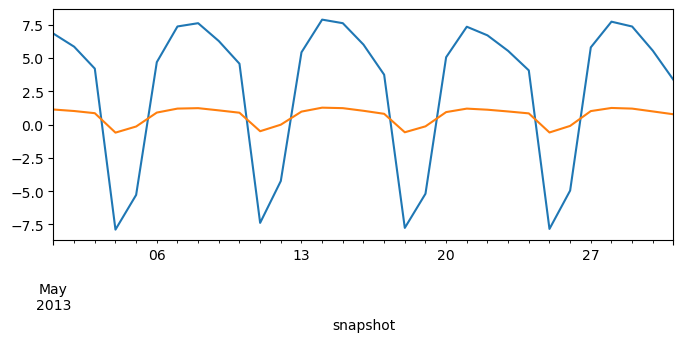

In [155]:
fig, ax = plt.subplots(figsize=(8, 3))
pipeline1.loc['2013-05'].plot(ax=ax)
pipeline2.loc['2013-05'].plot(ax=ax)

Looks interesting. Letz's check what is happening at the bus0. Note:
* when value p0 of link is positive = power is withdrawn from bus0
* when value p1 of link is positive = power is withdrawn from bus1
* when value p of bus is positive = net generation of power at bus

But watch out! The buses have a net power of zero because all the..
* generation of energy happens at the generators,
* the tranmission and energy conversion happens at the links,
* and the consumption of energy happens at the loads! 

It therefore is most useful to look into the links in order to see the transmission of energy.

Check the H2 links

In [130]:
h2_links = n.links.loc[n.links['carrier'] == 'H2 pipeline']

<Figure size 1200x3000 with 0 Axes>

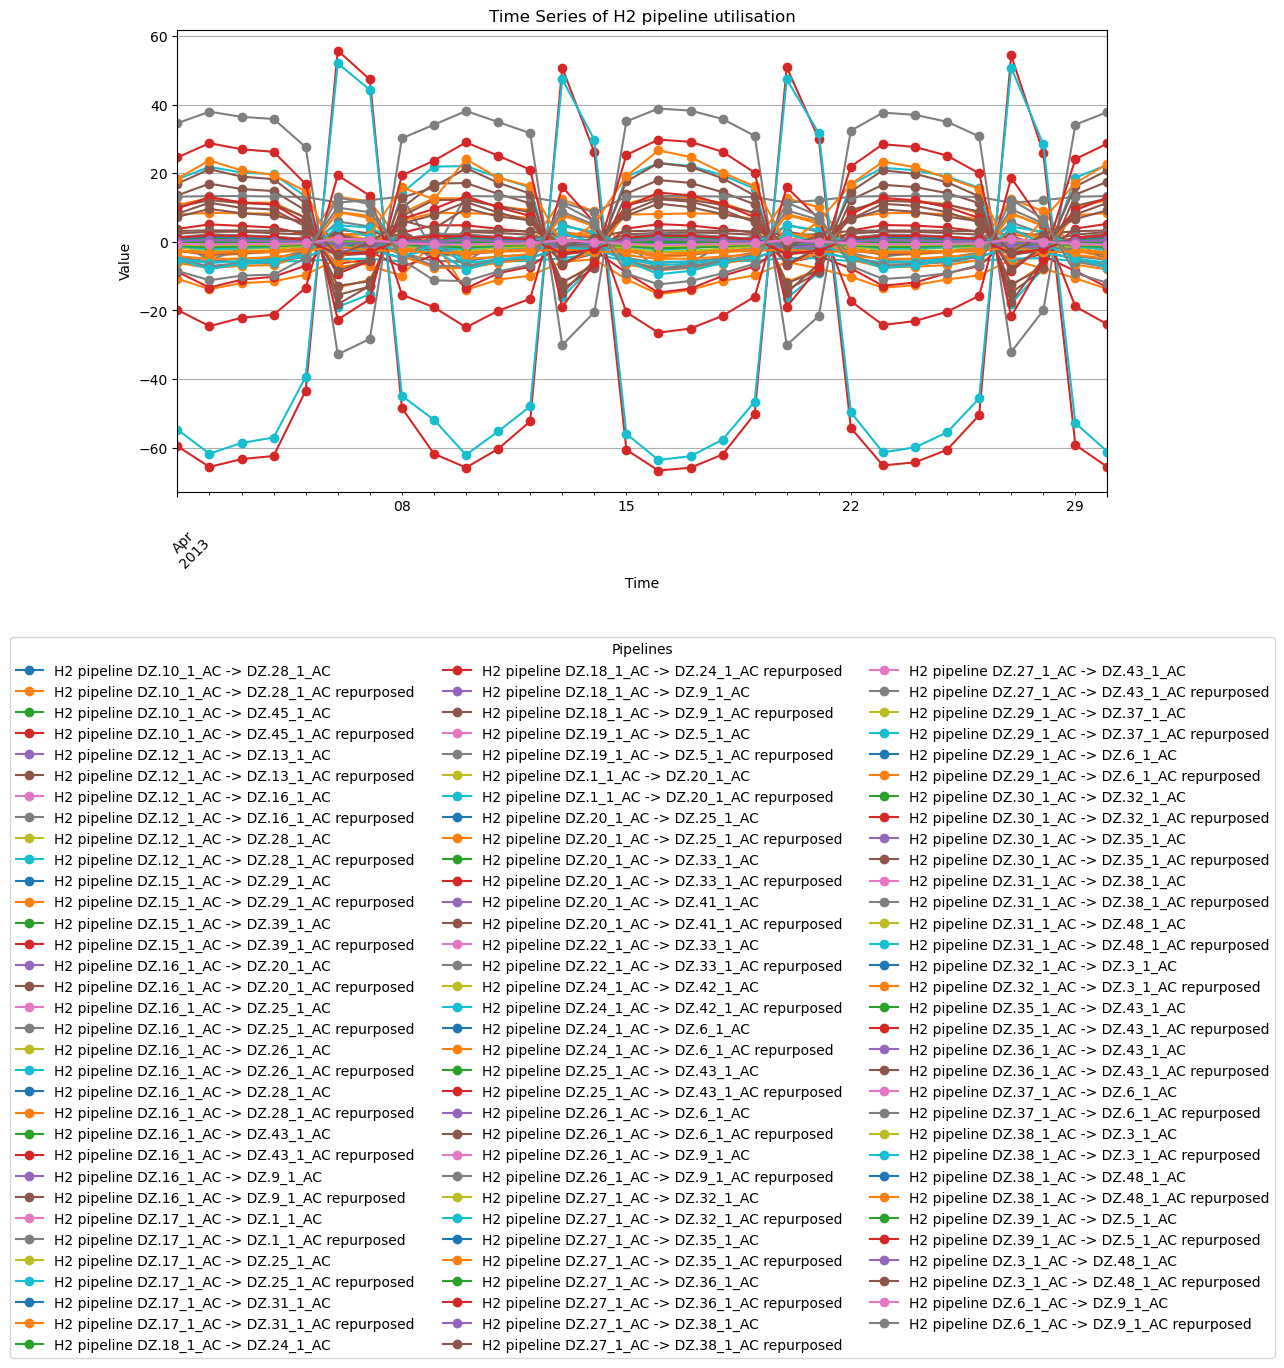

In [158]:
# Filter rows where the index contains "H2"
h2_links_data = n.links_t.p1.filter(like="H2 pipeline", axis=1)  # Assuming "H2" is in column names
h2_links_data = h2_links_data.multiply(n.snapshot_weightings.generators, axis=0)

# Plot
plt.figure(figsize=(12, 30))
h2_links_data.loc['2013-04'].plot(marker="o", linestyle="-", figsize=(12, 6), legend=None)

# Formatting
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series of H2 pipeline utilisation")
plt.legend(title="Pipelines", loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(True)
plt.xticks(rotation=45)

# Show plot
plt.show()

In [178]:
# Filter links where bus1 matches the given value
matching_links = n.links[n.links["bus1"] == "DZ.32_1_AC H2"]

# Get the names of these elements as a list
link_names = matching_links.index.tolist()

# Display the result
print(link_names)

['DZ.32_1_AC H2 Electrolysis', 'H2 pipeline DZ.27_1_AC -> DZ.32_1_AC repurposed', 'H2 pipeline DZ.30_1_AC -> DZ.32_1_AC repurposed', 'H2 pipeline DZ.27_1_AC -> DZ.32_1_AC', 'H2 pipeline DZ.30_1_AC -> DZ.32_1_AC', 'DZ.32_1_AC SMR CC', 'DZ.32_1_AC SMR']


<AxesSubplot:xlabel='snapshot'>

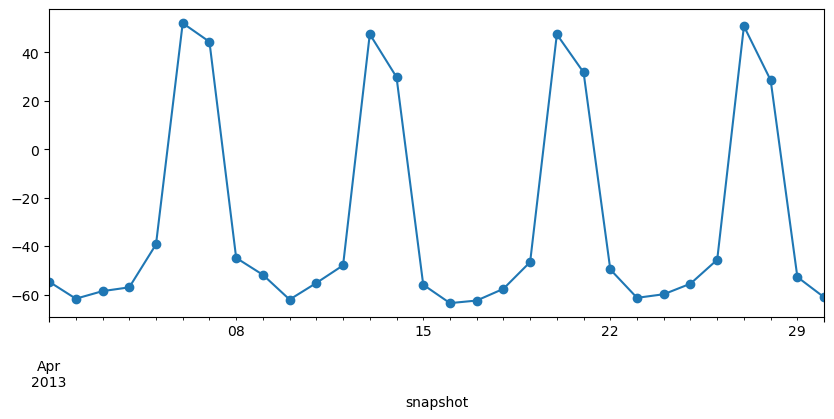

In [188]:
n.links_t.p1['H2 pipeline DZ.27_1_AC -> DZ.32_1_AC repurposed'].multiply(24).loc['2013-04'].plot(marker="o", linestyle="-", figsize=(10, 4), legend=None)

In [194]:
(n.links_t.p1[link_names]).multiply(24).sum() / 1e6

Link
DZ.32_1_AC H2 Electrolysis                        -0.000034
H2 pipeline DZ.27_1_AC -> DZ.32_1_AC repurposed   -0.008632
H2 pipeline DZ.30_1_AC -> DZ.32_1_AC repurposed   -0.003471
H2 pipeline DZ.27_1_AC -> DZ.32_1_AC              -0.000432
H2 pipeline DZ.30_1_AC -> DZ.32_1_AC              -0.000296
DZ.32_1_AC SMR CC                                 -9.918500
DZ.32_1_AC SMR                                    -0.000012
dtype: float64

We see that we have a huge SMR+CC plant installed at bus DZ.32_1_AC, generating an H2 output of about 1.1 GW constantly (-> 9.9 TWh H2 generation: basically almost all of the demand [10 TWh export]).

The bus is located in Oran at trhew North-Western part of the country at the coast. This is quite close to where the Medgaz pipeline enters into the Mediterranean sea.

Next question: Where can SMR be built? At existing gas power plants?

In [ ]:
n.statistics.energy_balance().loc[:,:,'H2'] # TWh

component  carrier                 
Load       H2                         -1.000000e+07
           H2 for shipping            -8.005011e+04
           land transport fuel cell   -1.805246e+05
Store      H2                         -4.468330e-05
           H2 Store Tank              -2.407796e-15
Link       Fischer-Tropsch            -7.336493e+02
           H2 Electrolysis             1.040549e+04
           H2 Fuel Cell               -2.865672e+02
           SMR                         8.386017e+02
           SMR CC                      1.025082e+07
           Sabatier                   -4.677156e+02
dtype: float64

In [23]:
gas_pipelines = n.links[n.links.carrier == 'H2 pipeline repurposed']
# gas_pipelines.count()

In [11]:
gas_pipelines = n.links[n.links.carrier == 'H2 pipeline repurposed']

# Convert to GeoDataFrame (assuming lat/lon available for buses)
buses = n.buses

gas_pipelines_gdf = gpd.GeoDataFrame({
    "from_bus": gas_pipelines.bus0,
    "to_bus": gas_pipelines.bus1
})

gas_pipelines_gdf["from_coords"] = gas_pipelines_gdf["from_bus"].map(buses[["x", "y"]].apply(lambda row: (float(row["x"]), float(row["y"])), axis=1))
gas_pipelines_gdf["to_coords"] = gas_pipelines_gdf["to_bus"].map(buses[["x", "y"]].apply(lambda row: (float(row["x"]), float(row["y"])), axis=1))


# Create LineString geometries
from shapely.geometry import LineString

gas_pipelines_gdf["geometry"] = gas_pipelines_gdf.apply(
    lambda row: LineString([row["from_coords"], row["to_coords"]]), axis=1
)

In [12]:
gas_pipelines_gdf.explore()

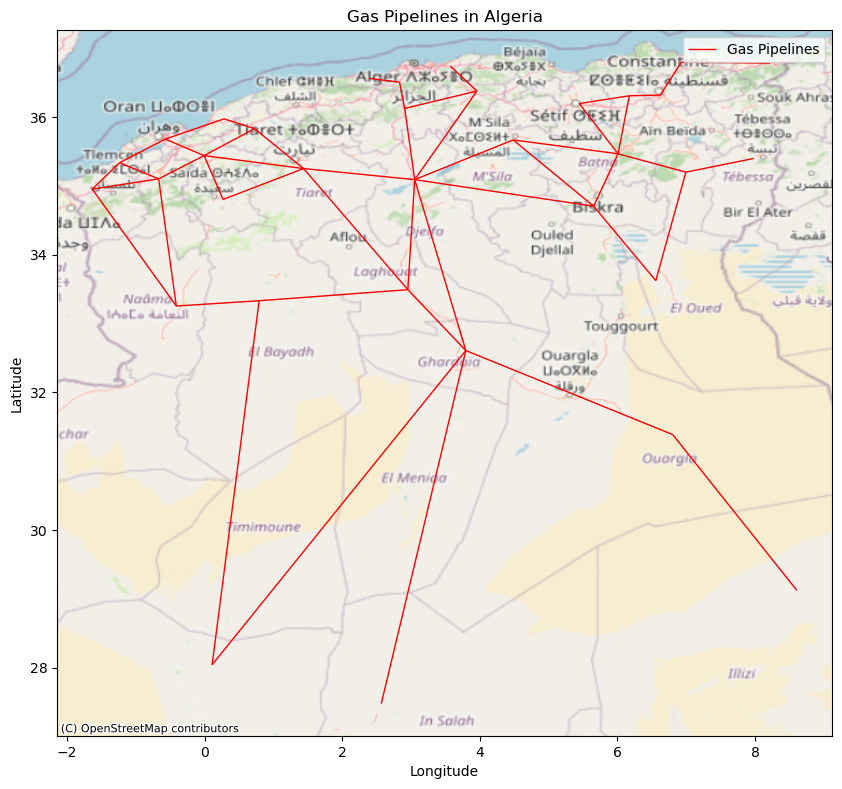

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Assuming 'gas_pipelines_gdf' contains your pipeline data with correct geometries

# Create the figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the pipelines
gas_pipelines_gdf.plot(ax=ax, color="red", linewidth=1, label="Gas Pipelines")

# Add a basemap of Algeria using contextily
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

# Customize the plot
ax.set_title("Gas Pipelines in Algeria")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# Show the plot
plt.show()


In [14]:
h2_pipelines = n.links[n.links.carrier == 'H2 pipeline']

In [15]:
# Convert to GeoDataFrame (assuming lat/lon available for buses)
buses = n.buses

h2_pipelines_gdf = gpd.GeoDataFrame({
    "from_bus": h2_pipelines.bus0,
    "to_bus": h2_pipelines.bus1
})

h2_pipelines_gdf["from_coords"] = h2_pipelines_gdf["from_bus"].map(buses[["x", "y"]].apply(lambda row: (float(row["x"]), float(row["y"])), axis=1))
h2_pipelines_gdf["to_coords"] = h2_pipelines_gdf["to_bus"].map(buses[["x", "y"]].apply(lambda row: (float(row["x"]), float(row["y"])), axis=1))


# Create LineString geometries
from shapely.geometry import LineString

h2_pipelines_gdf["geometry"] = h2_pipelines_gdf.apply(
    lambda row: LineString([row["from_coords"], row["to_coords"]]), axis=1
)

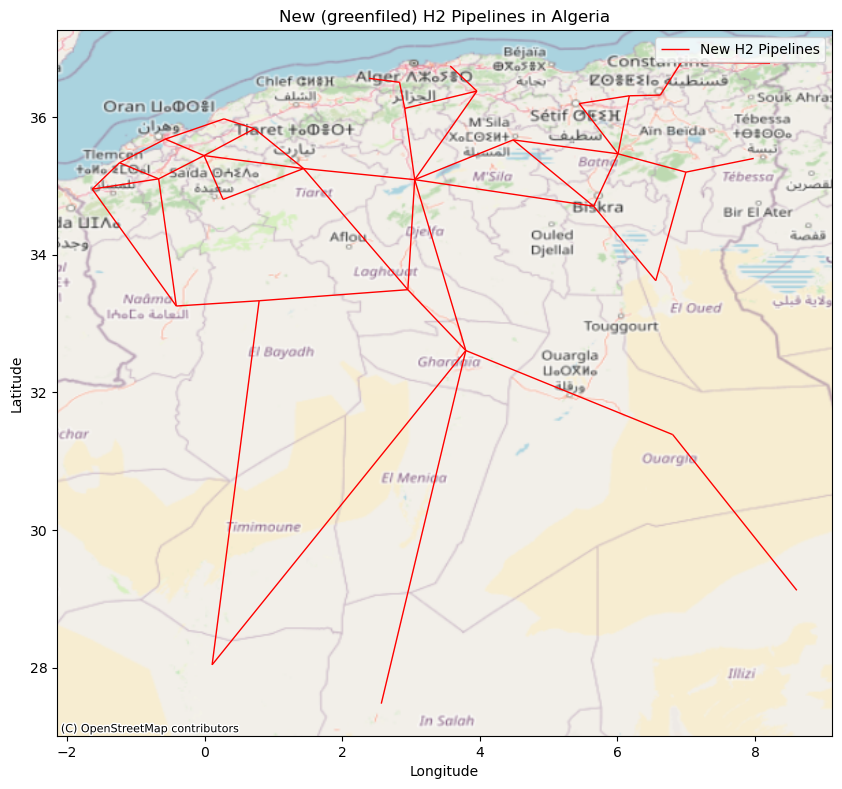

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Assuming 'h2_pipelines_gdf' contains your pipeline data with correct geometries

# Create the figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the pipelines
h2_pipelines_gdf.plot(ax=ax, color="red", linewidth=1, label="New H2 Pipelines")

# Add a basemap of Algeria using contextily
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

# Customize the plot
ax.set_title("New (greenfiled) H2 Pipelines in Algeria")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# Show the plot
plt.show()

In [ ]:
buses_grouped = n.buses.loc[n.buses['carrier'] == 'AC']
#print(buses_grouped)
buses_grouped.index
# buses_grouped.loc['DZ.22_1_AC']

Index(['DZ.10_1_AC', 'DZ.11_1_AC', 'DZ.12_1_AC', 'DZ.13_1_AC', 'DZ.14_1_AC',
       'DZ.15_1_AC', 'DZ.16_1_AC', 'DZ.17_1_AC', 'DZ.18_1_AC', 'DZ.19_1_AC',
       'DZ.1_1_AC', 'DZ.20_1_AC', 'DZ.21_1_AC', 'DZ.22_1_AC', 'DZ.23_1_AC',
       'DZ.24_1_AC', 'DZ.25_1_AC', 'DZ.26_1_AC', 'DZ.27_1_AC', 'DZ.28_1_AC',
       'DZ.29_1_AC', 'DZ.2_1_AC', 'DZ.30_1_AC', 'DZ.31_1_AC', 'DZ.32_1_AC',
       'DZ.33_1_AC', 'DZ.34_1_AC', 'DZ.35_1_AC', 'DZ.36_1_AC', 'DZ.37_1_AC',
       'DZ.38_1_AC', 'DZ.39_1_AC', 'DZ.3_1_AC', 'DZ.40_1_AC', 'DZ.41_1_AC',
       'DZ.42_1_AC', 'DZ.43_1_AC', 'DZ.45_1_AC', 'DZ.46_1_AC', 'DZ.47_1_AC',
       'DZ.48_1_AC', 'DZ.4_1_AC', 'DZ.5_1_AC', 'DZ.6_1_AC', 'DZ.7_1_AC',
       'DZ.8_1_AC', 'DZ.9_1_AC'],
      dtype='object', name='Bus')

In [ ]:
buses_grouped = n.buses.loc[n.buses['carrier'] == 'AC']
print(buses_grouped.gadm_1)

Bus
DZ.10_1_AC    DZ.10_1
DZ.11_1_AC    DZ.11_1
DZ.12_1_AC    DZ.12_1
DZ.13_1_AC    DZ.13_1
DZ.14_1_AC    DZ.14_1
DZ.15_1_AC    DZ.15_1
DZ.16_1_AC    DZ.16_1
DZ.17_1_AC    DZ.17_1
DZ.18_1_AC    DZ.18_1
DZ.19_1_AC    DZ.19_1
DZ.1_1_AC      DZ.1_1
DZ.20_1_AC    DZ.20_1
DZ.21_1_AC    DZ.21_1
DZ.22_1_AC    DZ.22_1
DZ.23_1_AC    DZ.23_1
DZ.24_1_AC    DZ.24_1
DZ.25_1_AC    DZ.25_1
DZ.26_1_AC    DZ.26_1
DZ.27_1_AC    DZ.27_1
DZ.28_1_AC    DZ.28_1
DZ.29_1_AC    DZ.29_1
DZ.2_1_AC      DZ.2_1
DZ.30_1_AC    DZ.30_1
DZ.31_1_AC    DZ.31_1
DZ.32_1_AC    DZ.32_1
DZ.33_1_AC    DZ.33_1
DZ.34_1_AC    DZ.34_1
DZ.35_1_AC    DZ.35_1
DZ.36_1_AC    DZ.36_1
DZ.37_1_AC    DZ.37_1
DZ.38_1_AC    DZ.38_1
DZ.39_1_AC    DZ.39_1
DZ.3_1_AC      DZ.3_1
DZ.40_1_AC    DZ.40_1
DZ.41_1_AC    DZ.41_1
DZ.42_1_AC    DZ.42_1
DZ.43_1_AC    DZ.43_1
DZ.45_1_AC    DZ.45_1
DZ.46_1_AC    DZ.46_1
DZ.47_1_AC    DZ.47_1
DZ.48_1_AC    DZ.48_1
DZ.4_1_AC      DZ.4_1
DZ.5_1_AC      DZ.5_1
DZ.6_1_AC      DZ.6_1
DZ.7_1_AC      DZ.7_1
DZ.8_1

## Tryout: Show constraint

In [ ]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-116.059939,primary_energy,NaN,co2_emissions,0.0


List the snapshots of the PyPSA network

In [ ]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='snapshot', length=365, freq=None)
Time steps: 365


## Analyse energy system

### Transport Sector 
The demand of EVs, ICE (internal combustion engine) and FCEV (fuell cell)

In [ ]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
transport_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains(
    'land transport oil(?! emissions)|land transport fuel cell|land transport EV', 
    case=True)]
transport_stats_GWh

component  carrier                   bus_carrier
Load       land transport EV         Li ion        -1.281686e+05
           land transport fuel cell  H2            -1.805246e+05
           land transport oil        oil           -2.948568e+07
Name: objective, dtype: float64

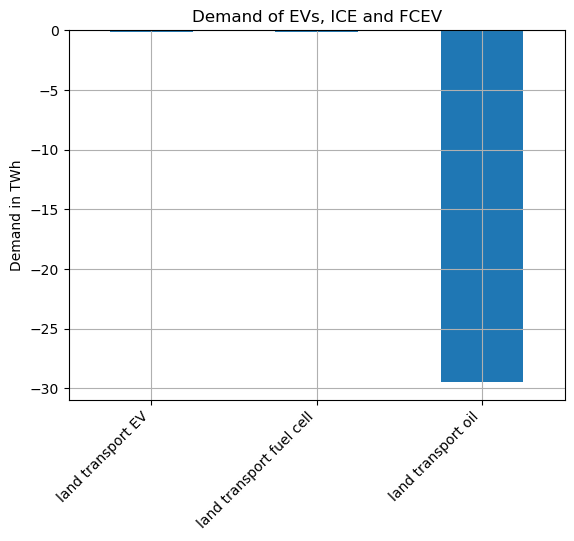

In [ ]:
transport_stats_TWh = transport_stats_GWh/1000000

ax = transport_stats_TWh.plot.bar(
    title='Demand of EVs, ICE and FCEV',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(transport_stats_GWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True) 
plt.show()

### Heating Sector 
The demand of various heating subsectors

In [ ]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
heating_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains('heat', case=False)]
heating_stats_GWh

component  carrier                           bus_carrier                     
Load       residential rural heat            residential rural heat                 -3.560775
           residential urban decentral heat  residential urban decentral heat       -9.533842
           urban central heat                urban central heat                 -15214.844823
Name: objective, dtype: float64

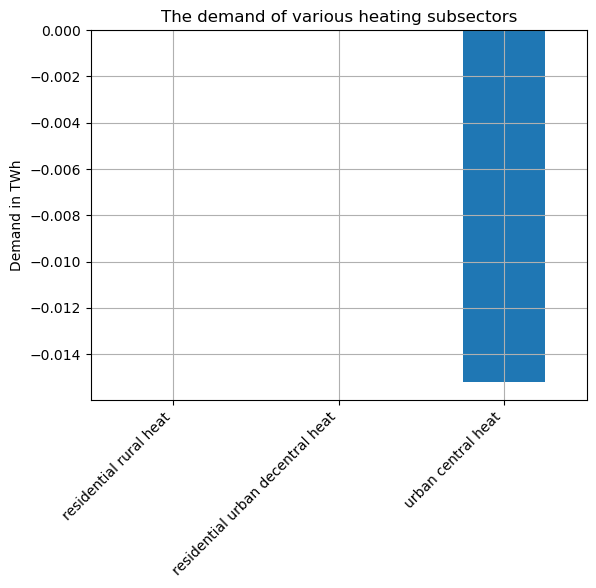

In [ ]:
heating_stats_TWh = heating_stats_GWh/1000000

ax = heating_stats_TWh.plot.bar(
    title='The demand of various heating subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(heating_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()

How is heating energy supplied (heat pump, district heating, resistive heater, gas boiler)

Gas Boiler: 2319.47890998783 MWh
Heat Pump: 6473.482549379891 MWh
Resistive Heater: 5346.327585367548 MWh
CHP: 207935544.60100943 MWh


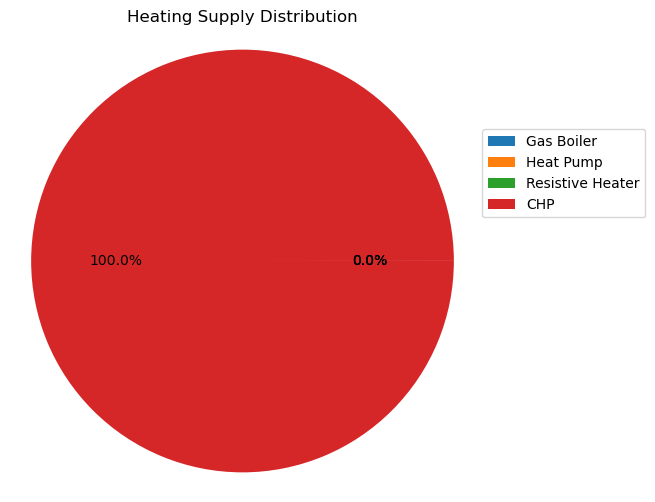

In [ ]:
heating_supply_stats = n.statistics.supply(comps=["Link"], aggregate_time="sum").loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
]

# Only the Gas boiler, heat pump, CHP, and resistive heater technologies are considered here
heating_types = ['Gas Boiler', 'Heat Pump', 'Resistive Heater', 'CHP']
heating_sums = [heating_supply_stats[heating_supply_stats.index.get_level_values('carrier').str.contains(heatingtype, case=False)].sum() for heatingtype in heating_types]

for ht, sum_value in zip(heating_types, heating_sums):
    print(f"{ht}: {sum_value} MWh")

plt.figure(figsize=(6, 6))
plt.pie(heating_sums, autopct='%1.1f%%')
plt.title('Heating Supply Distribution')
plt.legend(heating_types, loc='upper left', bbox_to_anchor=(1, 0.8))
plt.axis('equal')
plt.show()

### Electricity Sector 
The share of different carriers (capacity and energy)

In [ ]:
def color_matching(stats):
    colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
    nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}
    color_list = []
    for carrier in stats.index.get_level_values("carrier"):
        original_name = carrier.lower()
        key_name = nice_names.get(original_name, original_name)
        color = colors.get(key_name.lower(), 'gray')
        color_list.append(color)
    return color_list

In [ ]:
capacity_stats = n.statistics.installed_capacity(comps=["Generator"])
# Remove carrier with the capacity = 0
capacity_stats_non_zero = capacity_stats[capacity_stats != 0].dropna()
capacity_stats_plus = n.statistics.installed_capacity(comps=["StorageUnit"])
combined_capacity_stats = pd.concat([capacity_stats_non_zero, capacity_stats_plus])
combined_capacity_stats

component    carrier           
Generator    Combined-Cycle Gas    2.963506e+04
             Onshore Wind          9.506088e+00
             Run of River          2.137791e+01
             Solar                 4.258000e+02
             load                  1.132000e+12
StorageUnit  Reservoir & Dam       1.000000e+02
Name: p_nom, dtype: float64

In [ ]:
n.generators

,carrier,bus,p_nom_min,p_nom,p_nom_extendable,efficiency,marginal_cost,capital_cost,p_nom_max,weight,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
DZ.10_1_AC CCGT,CCGT,DZ.10_1_AC,1310.000000,1.310000e+03,False,0.5,47.209920,84469.122809,inf,2.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.10_1_AC onwind,onwind,DZ.10_1_AC,0.000000,0.000000e+00,True,1.0,0.025793,109295.569252,2.092725e+03,230.496999,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.10_1_AC solar,solar,DZ.10_1_AC,0.161015,1.610154e-01,True,1.0,0.019380,38283.380189,4.160493e+03,645.080052,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.11_1_AC onwind,onwind,DZ.11_1_AC,0.000000,0.000000e+00,True,1.0,0.024412,109295.569252,8.710040e+03,609.722534,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.11_1_AC solar,solar,DZ.11_1_AC,0.631865,6.318655e-01,True,1.0,0.020034,38283.380189,1.594377e+04,2530.680827,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DZ.6_1_AC home battery load,load,DZ.6_1_AC home battery,0.000000,1.000000e+09,False,1.0,100.009403,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.7_1_AC home battery load,load,DZ.7_1_AC home battery,0.000000,1.000000e+09,False,1.0,100.010127,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.8_1_AC home battery load,load,DZ.8_1_AC home battery,0.000000,1.000000e+09,False,1.0,100.010095,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [ ]:
print(n.generators.groupby('carrier').p_nom.sum())

carrier
CCGT                                         2.963506e+04
biomass                                      0.000000e+00
coal                                         0.000000e+00
gas                                          0.000000e+00
lignite                                      0.000000e+00
load                                         1.132000e+12
offwind-ac                                   0.000000e+00
offwind-dc                                   0.000000e+00
oil                                          0.000000e+00
onwind                                       9.506088e+00
residential rural solar thermal              0.000000e+00
residential urban decentral solar thermal    0.000000e+00
ror                                          2.137791e+01
services rural solar thermal                 0.000000e+00
services urban decentral solar thermal       0.000000e+00
solar                                        4.258000e+02
solar rooftop                                0.000000e+00
urban 

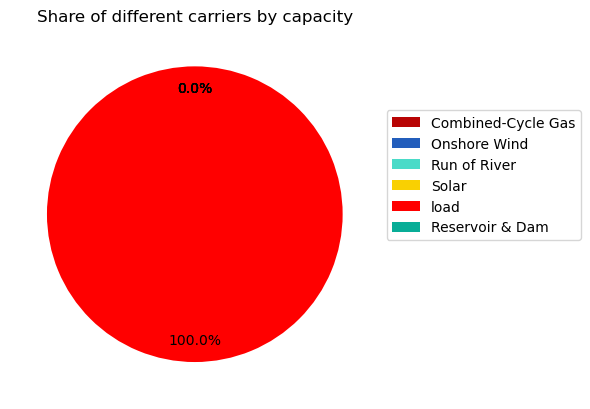

In [ ]:
color_list = color_matching(combined_capacity_stats)

combined_capacity_stats.plot.pie(
    title="Share of different carriers by capacity",
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,
)

custom_labels = combined_capacity_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))


## Tryout: Get rid of load

In [ ]:
combined_capacity_stats_v2 = combined_capacity_stats[
    combined_capacity_stats.index.get_level_values("carrier") != "load"
]

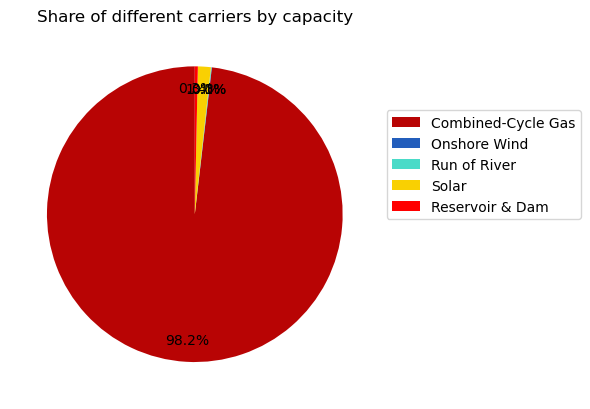

In [ ]:
color_list = color_matching(combined_capacity_stats)

combined_capacity_stats_v2.plot.pie(
    title="Share of different carriers by capacity",
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,
)

custom_labels = combined_capacity_stats_v2.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))

In [ ]:
energy_stats = n.statistics.energy_balance(comps=["Generator"])
electricity_energy_stats = energy_stats[energy_stats.index.get_level_values('bus_carrier') == 'AC']
electricity_energy_stats_plus = n.statistics.energy_balance(comps=["StorageUnit"])
combined_electricity_energy_stats = pd.concat([electricity_energy_stats, electricity_energy_stats_plus])
combined_electricity_energy_stats

component    carrier             bus_carrier
Generator    Combined-Cycle Gas  AC                139.758692
             Offshore Wind (AC)  AC                  0.918047
             Onshore Wind        AC              21669.798640
             Run of River        AC             187256.669752
             Solar               AC             675447.158781
StorageUnit  Reservoir & Dam     AC             122143.870299
dtype: float64

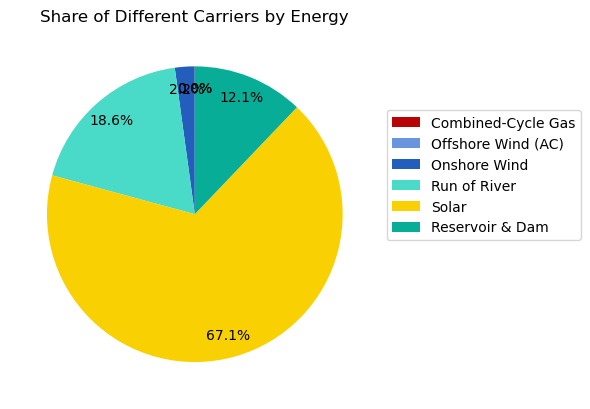

In [ ]:
color_list = color_matching(combined_electricity_energy_stats)

combined_electricity_energy_stats.plot.pie(
    title='Share of Different Carriers by Energy',
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,  
)

custom_labels = combined_electricity_energy_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))

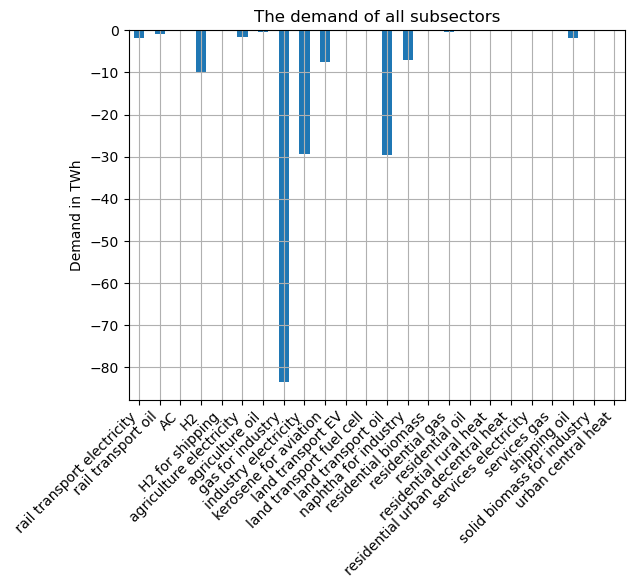

In [ ]:
load_stats_TWh = load_stats / 1000000

energy_load_stats_TWh = load_stats_TWh[~load_stats.index.get_level_values('bus_carrier').str.contains('co2|process emissions', case=False)] 

ax = energy_load_stats_TWh.plot.bar(
    title='The demand of all subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(energy_load_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()


In [ ]:
print(energy_load_stats_TWh.index.get_level_values('bus_carrier'))

Index(['low voltage', 'oil', 'low voltage', 'H2', 'H2', 'low voltage', 'oil',
       'gas for industry', 'low voltage', 'oil', 'Li ion', 'H2', 'oil', 'oil',
       'biomass', 'gas', 'oil', 'residential rural heat',
       'residential urban decentral heat', 'low voltage', 'gas', 'oil',
       'solid biomass for industry', 'urban central heat'],
      dtype='object', name='bus_carrier')


In [ ]:
load_stats.index.get_level_values('bus_carrier')

Index(['low voltage', 'oil', 'low voltage', 'H2', 'H2', 'low voltage', 'oil',
       'co2', 'gas for industry', 'co2', 'low voltage', 'co2', 'oil', 'Li ion',
       'H2', 'oil', 'co2', 'oil', 'co2', 'process emissions', 'biomass', 'gas',
       'oil', 'residential rural heat', 'residential urban decentral heat',
       'low voltage', 'gas', 'oil', 'co2', 'solid biomass for industry',
       'urban central heat'],
      dtype='object', name='bus_carrier')

In [ ]:
load_stats_TWh

component  carrier                           bus_carrier                     
Load        rail transport electricity       low voltage                         -1.854823
            rail transport oil               oil                                 -0.807022
           AC                                low voltage                         -0.132441
           H2                                H2                                 -10.000000
           H2 for shipping                   H2                                  -0.080050
           agriculture electricity           low voltage                         -1.588492
           agriculture oil                   oil                                 -0.332755
           gas emissions                     co2                                  0.066624
           gas for industry                  gas for industry                   -83.491555
           industry coal emissions           co2                                  0.474554
           i

carrier
CCGT                                         1.397587e-04
biomass                                      1.450005e+02
coal                                         0.000000e+00
gas                                          1.079636e+02
lignite                                      0.000000e+00
load                                         1.281688e+02
offwind-ac                                   9.180471e-07
offwind-dc                                   0.000000e+00
oil                                          2.449881e-04
onwind                                       2.166980e-02
residential rural solar thermal              0.000000e+00
residential urban decentral solar thermal    0.000000e+00
ror                                          1.872567e-01
services rural solar thermal                 0.000000e+00
services urban decentral solar thermal       0.000000e+00
solar                                        6.754472e-01
solar rooftop                                1.931160e-03
urban 

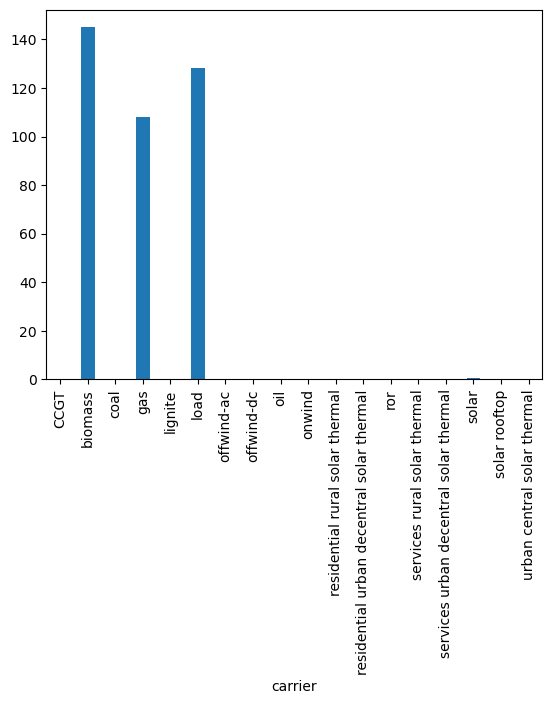

In [ ]:
# Sum total electricity generation per carrier
generation = n.generators_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

# Group by carrier (e.g., solar, wind, coal)
total_generation_per_carrier_TWh = generation.groupby(n.generators.carrier).sum() / 1000000

print(total_generation_per_carrier_TWh)

total_generation_per_carrier_TWh.plot.bar()

print(total_generation_per_carrier_TWh.sum())

In [ ]:
total_consumption_perLoad = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

# Sum across all buses
total_consumption = total_consumption_perLoad.sum()

print(f"Total energy consumption: {total_consumption} MWh")
total_consumption_perLoad

Total energy consumption: 104382447.33734044 MWh


Load
DZ.10_1_AC                              4013.097849
DZ.10_1_AC H2 for industry                 0.000000
DZ.10_1_AC H2 for shipping                 0.000000
DZ.10_1_AC agriculture electricity     84900.965315
DZ.10_1_AC agriculture oil             17784.917735
                                          ...      
residential gas emissions             -64605.931666
residential oil emissions              -6397.563538
services gas emissions                 -2018.308782
services oil emissions                     0.000000
shipping oil emissions               -390914.209543
Length: 1421, dtype: float64

In [ ]:
total_storage = n.stores_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

print(total_storage.sum() / 1000000)

-44.19110773590393
